In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

HERE = Path.cwd().resolve()
ANALYSIS_ROOT = next((p for p in (HERE, *HERE.parents) if (p / 'seacofs_tilt_tools.py').exists()), None)
if ANALYSIS_ROOT is None:
    raise FileNotFoundError('Run from seacofs_eddy_tilt_analysis or one of its subfolders.')
CASE_ROOT = ANALYSIS_ROOT / 'case_studies'
for path in (ANALYSIS_ROOT, CASE_ROOT):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

import seacofs_tilt_tools as tilt
from case_study_tools import (PVAlignmentConfig, add_pv_alignment_diagnostics,
                              plot_eddy_timeline)

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 60)

In [2]:
DOMINANCE_FACTOR = 2.0
MIN_DEPTH_m = 3000.0
MIN_TILT_km = 0.0

paths = tilt.Paths()
grid = tilt.load_grid(paths.grid, paths.z_r)
df_eddies, _ = tilt.load_tilt_tables(paths)
df_eddies = tilt.add_region_labels(df_eddies, grid)
df_eddies = tilt.add_pv_gradient_terms(df_eddies, grid, core_mean=True)

config = PVAlignmentConfig(
    dominance_factor=DOMINANCE_FACTOR,
    min_open_ocean_depth_m=MIN_DEPTH_m,
    min_tilt_distance_km=MIN_TILT_km,
)
d = add_pv_alignment_diagnostics(df_eddies, config)
assert d.beta.dropna().median() > 0, 'Expected positive planetary beta after gradient sign correction.'
planetary = d[d.open_ocean_planetary & d.direction_valid].copy()

# Compass bearing: 0° = north and 90° = east.
planetary['tilt_x_km'] = planetary.TiltDis * np.sin(np.deg2rad(planetary.TiltDir))
planetary['tilt_y_km'] = planetary.TiltDis * np.cos(np.deg2rad(planetary.TiltDir))

In [3]:
full = df_eddies.groupby('Eddy').size()
kept = planetary.groupby('Eddy').size()

# complete_eddies = full.index[(full - kept.reindex(full.index, fill_value=0)).eq(6)]
complete_eddies = full.index[(full - kept.reindex(full.index, fill_value=0)) < 10]
df_eddies[df_eddies.Eddy.isin(complete_eddies)].groupby('Cyc').Eddy.nunique()


Cyc
AE    19
CE     4
Name: Eddy, dtype: int64

(np.float64(0.0),
 np.float64(988.1356688684336),
 np.float64(0.0),
 np.float64(1561.702894718129))

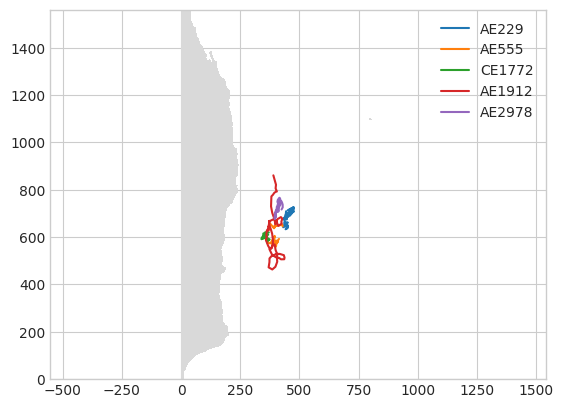

In [4]:
df_complete = planetary[(planetary.Eddy.isin(complete_eddies))&(planetary.Age>30)].copy()

plt.contourf(grid.X_grid, grid.Y_grid, np.where(grid.mask_rho, np.nan,0))
for eddy in df_complete.Eddy.unique():
    df = df_complete[df_complete.Eddy==eddy].copy()
    plt.plot(df.xc, df.yc, label=f'{df.iloc[0].Cyc}{eddy}')
plt.legend()
plt.axis('equal')

(array([ 9., 13.,  2.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         3.,  3.,  9., 22., 15., 24., 28., 35., 25., 25.,  5.,  5.,  1.,
         0.,  0.,  0.,  1.]),
 array([-1.89423584e-05, -1.63815324e-05, -1.38207064e-05, -1.12598804e-05,
        -8.69905435e-06, -6.13822833e-06, -3.57740231e-06, -1.01657629e-06,
         1.54424973e-06,  4.10507576e-06,  6.66590178e-06,  9.22672780e-06,
         1.17875538e-05,  1.43483798e-05,  1.69092059e-05,  1.94700319e-05,
         2.20308579e-05,  2.45916839e-05,  2.71525099e-05,  2.97133360e-05,
         3.22741620e-05,  3.48349880e-05,  3.73958140e-05,  3.99566401e-05,
         4.25174661e-05,  4.50782921e-05,  4.76391181e-05,  5.01999441e-05,
         5.27607702e-05,  5.53215962e-05,  5.78824222e-05]),
 <BarContainer object of 30 artists>)

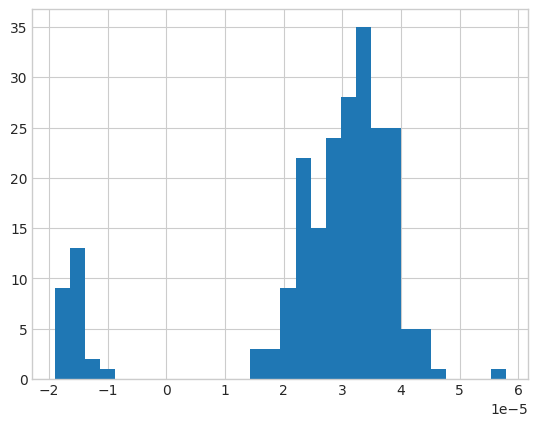

In [5]:
plt.hist(df_complete.w, bins=30)

(array([ 6., 25., 38., 43., 24.,  7., 16., 12.,  6., 10.,  6.,  7.,  7.,
         5.,  4.,  4.,  2.,  1.,  0.,  0.,  0.,  1.,  0.,  0.,  0.,  1.,
         0.,  0.,  0.,  1.]),
 array([ 0.78011576,  3.06001083,  5.3399059 ,  7.61980097,  9.89969605,
        12.17959112, 14.45948619, 16.73938127, 19.01927634, 21.29917141,
        23.57906649, 25.85896156, 28.13885663, 30.41875171, 32.69864678,
        34.97854185, 37.25843693, 39.538332  , 41.81822707, 44.09812215,
        46.37801722, 48.65791229, 50.93780737, 53.21770244, 55.49759751,
        57.77749259, 60.05738766, 62.33728273, 64.61717781, 66.89707288,
        69.17696795]),
 <BarContainer object of 30 artists>)

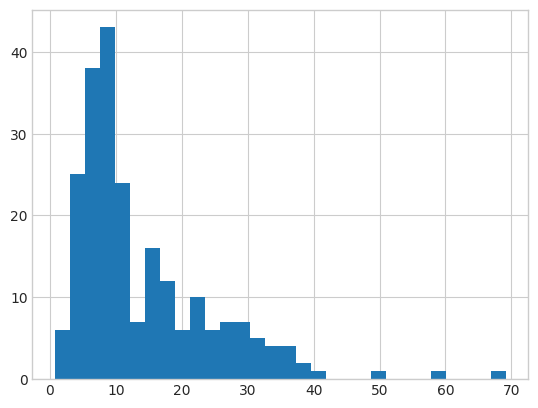

In [6]:
plt.hist(df_complete.TiltDis, bins=30)

(array([ 1.,  0.,  0.,  0.,  3.,  3., 13., 19., 26., 33., 28., 20., 19.,
        19., 10.,  4.,  3.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         1.,  2., 11., 11.]),
 array([-0.70485555, -0.67372874, -0.64260192, -0.61147511, -0.5803483 ,
        -0.54922149, -0.51809467, -0.48696786, -0.45584105, -0.42471424,
        -0.39358742, -0.36246061, -0.3313338 , -0.30020698, -0.26908017,
        -0.23795336, -0.20682655, -0.17569973, -0.14457292, -0.11344611,
        -0.08231929, -0.05119248, -0.02006567,  0.01106114,  0.04218796,
         0.07331477,  0.10444158,  0.1355684 ,  0.16669521,  0.19782202,
         0.22894883]),
 <BarContainer object of 30 artists>)

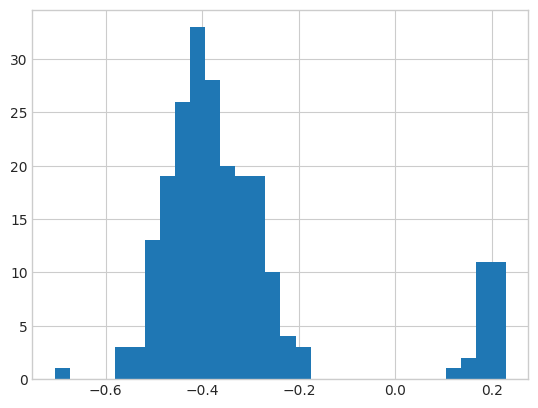

In [7]:
plt.hist(df_complete.Ro, bins=30)

(array([ 1.,  0.,  0.,  1.,  0.,  0.,  1.,  0.,  2.,  3.,  3.,  8.,  5.,
        12., 11.,  8., 22., 26., 29., 30., 17.,  7., 12., 13.,  7.,  3.,
         2.,  1.,  1.,  1.]),
 array([-4.31591804, -4.17432774, -4.03273743, -3.89114712, -3.74955681,
        -3.60796651, -3.4663762 , -3.32478589, -3.18319558, -3.04160527,
        -2.90001497, -2.75842466, -2.61683435, -2.47524404, -2.33365373,
        -2.19206343, -2.05047312, -1.90888281, -1.7672925 , -1.6257022 ,
        -1.48411189, -1.34252158, -1.20093127, -1.05934096, -0.91775066,
        -0.77616035, -0.63457004, -0.49297973, -0.35138943, -0.20979912,
        -0.06820881]),
 <BarContainer object of 30 artists>)

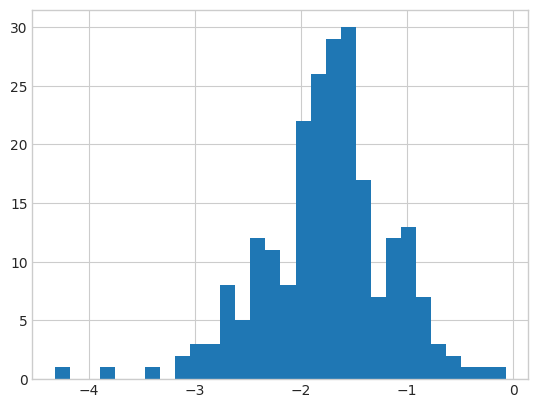

In [8]:
plt.hist(df_complete.topo_plan_ratio, bins=30)

In [9]:
def time_plot(eddy, df_data):
    return plot_eddy_timeline(eddy, df_data, grid, config=config)
    df = df_data[df_data.Eddy.eq(eddy)].copy()
    t = df.Day - df.Day.iloc[0]

    fig = plt.figure(figsize=(12,10))
    gs = fig.add_gridspec(6, 2, width_ratios=[2,1])
    axs = [fig.add_subplot(gs[i,0]) for i in range(6)]
    south = df.TiltDir.between(90, 270)
    for ax in axs:
        for i in np.where(south)[0]:
            ax.axvspan(t.iloc[i]-.5, t.iloc[i]+.5, color='grey', alpha=.12, lw=0)
    axm = fig.add_subplot(gs[:,1])

    axs[0].plot(t, df.TiltDis)
    axs[0].set_ylabel('TiltDis')
    ax0 = axs[0].twinx()
    ax0.plot(t, df.PV_grad_mag, color='tab:red')
    ax0.set_ylabel('PV grad mag', color='tab:red')

    axs[1].plot(t, np.exp(df.topo_plan_ratio))
    axs[1].plot(t, np.exp(df.topo_plan_ratio_smooth))
    axs[1].set_ylabel('Topo/plan')

    axs[2].plot(t, df.Ro)
    axs[2].set_ylabel('Ro')
    ax2 = axs[2].twinx()
    ax2.plot(t, df.w, color='tab:red', label='w')
    # ax2.plot(t, df.f, color='tab:orange', label='f')
    ax2.set_ylabel('w')

    axs[3].plot(t, df.PV)
    axs[3].set_ylabel('PV')
    ax3 = axs[3].twinx()
    ax3.plot(t, df.h, color='tab:red')
    ax3.set_ylabel('h', color='tab:red')

    axs[4].plot(t, df.beta)
    axs[4].set_ylabel('beta')
    ax4 = axs[4].twinx()
    ax4.plot(t, df.w+df.f, color='tab:red')
    ax4.set_ylabel('abs_vort = w + f', #'Latitude', 
                   color='tab:red')

    axs[5].scatter(t, df.PV_grad_theta, s=10, label='PV grad')
    axs[5].scatter(t, df.TiltDir, s=10, label='Tilt')
    axs[5].plot(t, df.TiltDir)
    axs[5].scatter(t, df.dtheta_PV_grad, s=10, label=r'$\Delta\theta$')
    axs[5].axhspan(90, 270, color='grey', alpha=.15)
    axs[5].set(xlabel='Eddy age [days]', ylabel='Direction [°]')
    axs[5].legend()

    th = np.deg2rad(df.TiltDir)
    xb = df.xc - df.TiltDis*np.sin(th)
    yb = df.yc - df.TiltDis*np.cos(th)

    cyc = df.iloc[0].Cyc
    clr = 'r' if cyc == 'AE' else 'b'
    axm.plot(df.xc, df.yc, '.-', color=clr, label='Surface')
    axm.scatter(xb, yb, s=10, color=clr, label='Bottom')
    for xs, ys, xbot, ybot, theta in zip(df.xc, df.yc, xb, yb, df.TiltDir):
        equatorward = (theta < 90) | (theta > 270)
        clr = 'magenta' if equatorward else 'c'
        axm.plot([xs, xbot], [ys, ybot], color=clr, alpha=.25)

    axm.set(xlabel='x (km)', ylabel='y (km)')
    axm.set_aspect('equal')
    axm.legend()

    fig.suptitle(f'{cyc}{eddy}')
    plt.tight_layout()

In [10]:
df_complete.columns

Index(['Eddy', 'Day', 'Cyc', 'lon', 'lat', 'ic', 'jc', 'xc', 'yc', 'w',
       'Omega', 'q11', 'q12', 'q22', 'Rc', 'psi0', 'AR', 'R', 'Age', 'Date',
       'fname', 'TiltDis', 'TiltDir', 'Region', 'f', 'h', 'dhdx', 'dhdy',
       'beta', 'abs_vort', 'PV', 'PV_grad_plan_x', 'PV_grad_plan_y',
       'PV_grad_topo_x', 'PV_grad_topo_y', 'PV_grad_x', 'PV_grad_y',
       'PV_grad_plan_mag', 'PV_grad_plan_theta', 'PV_grad_topo_mag',
       'PV_grad_topo_theta', 'PV_grad_mag', 'PV_grad_theta', 'dtheta_PV_grad',
       'dtheta_PV_grad_topo', 'dtheta_PV_grad_plan', 'Ro', 'topo_plan_ratio',
       'topo_plan_ratio_smooth', 'planetary_strong', 'open_ocean_planetary',
       'topographic_strong', 'shallow_ocean_topographic',
       'signed_dtheta_PV_grad', 'expected_PV_theta',
       'expected_direction_error', 'direction_valid', 'expected_match',
       'tilt_x_km', 'tilt_y_km'],
      dtype='object')

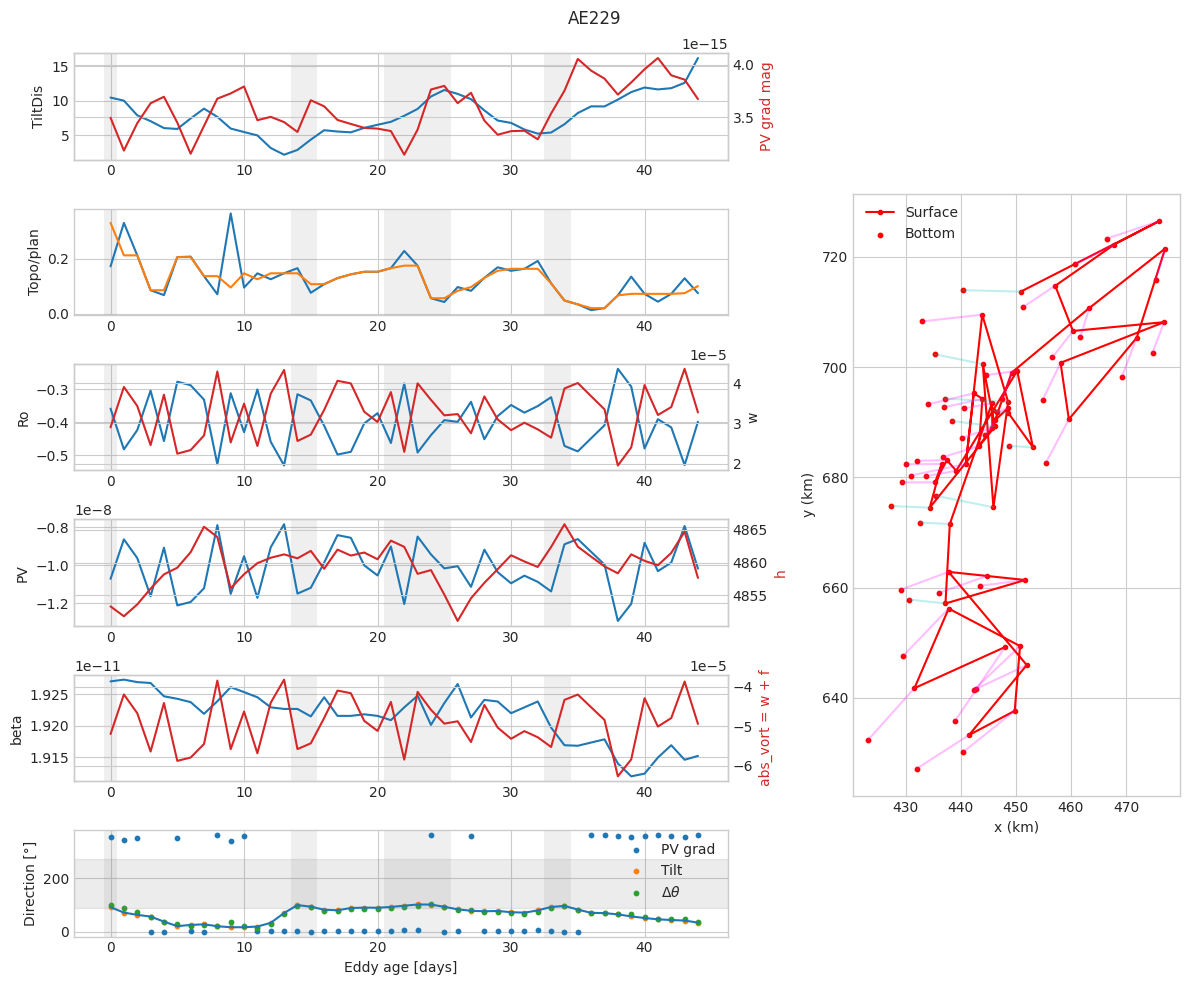

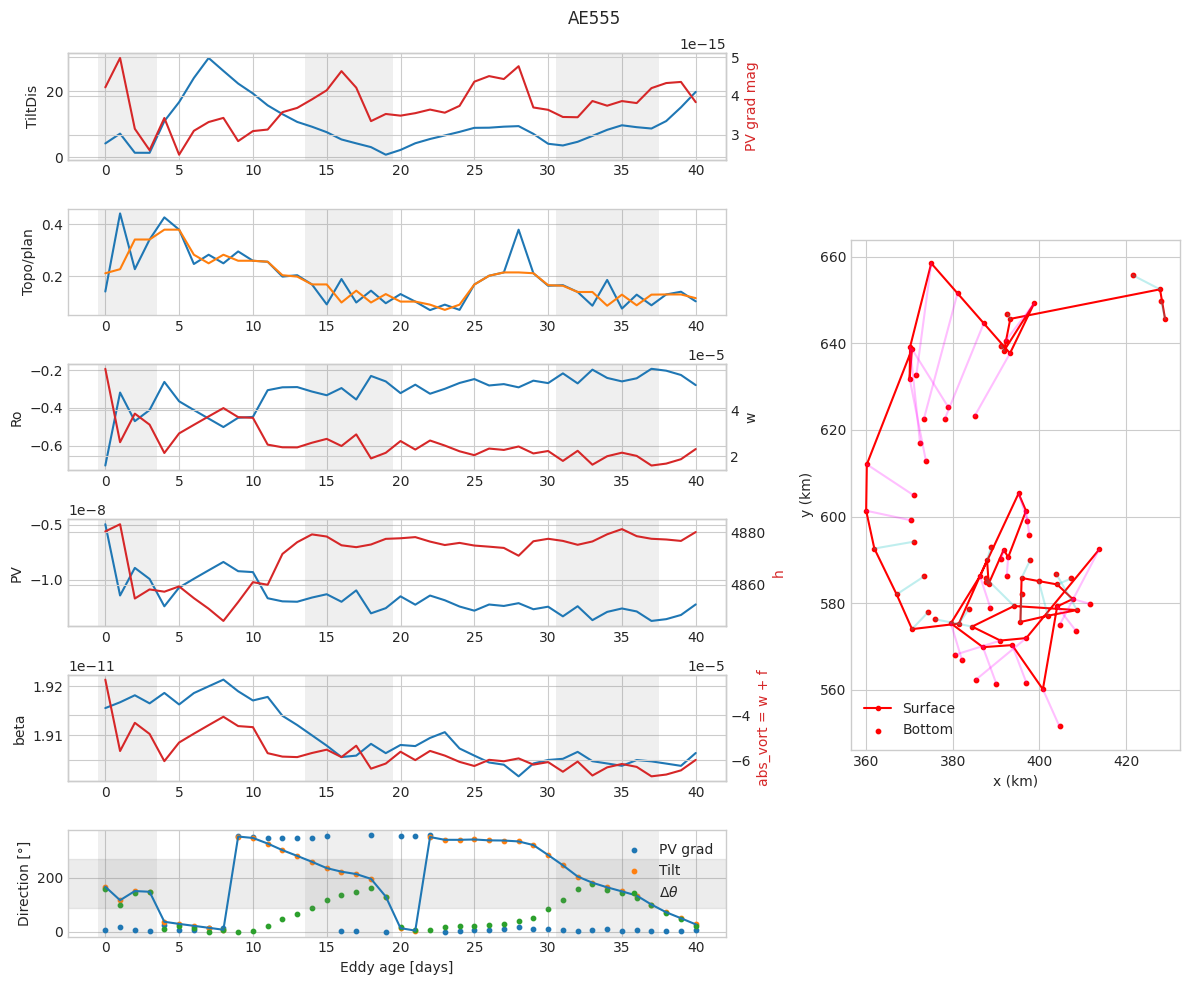

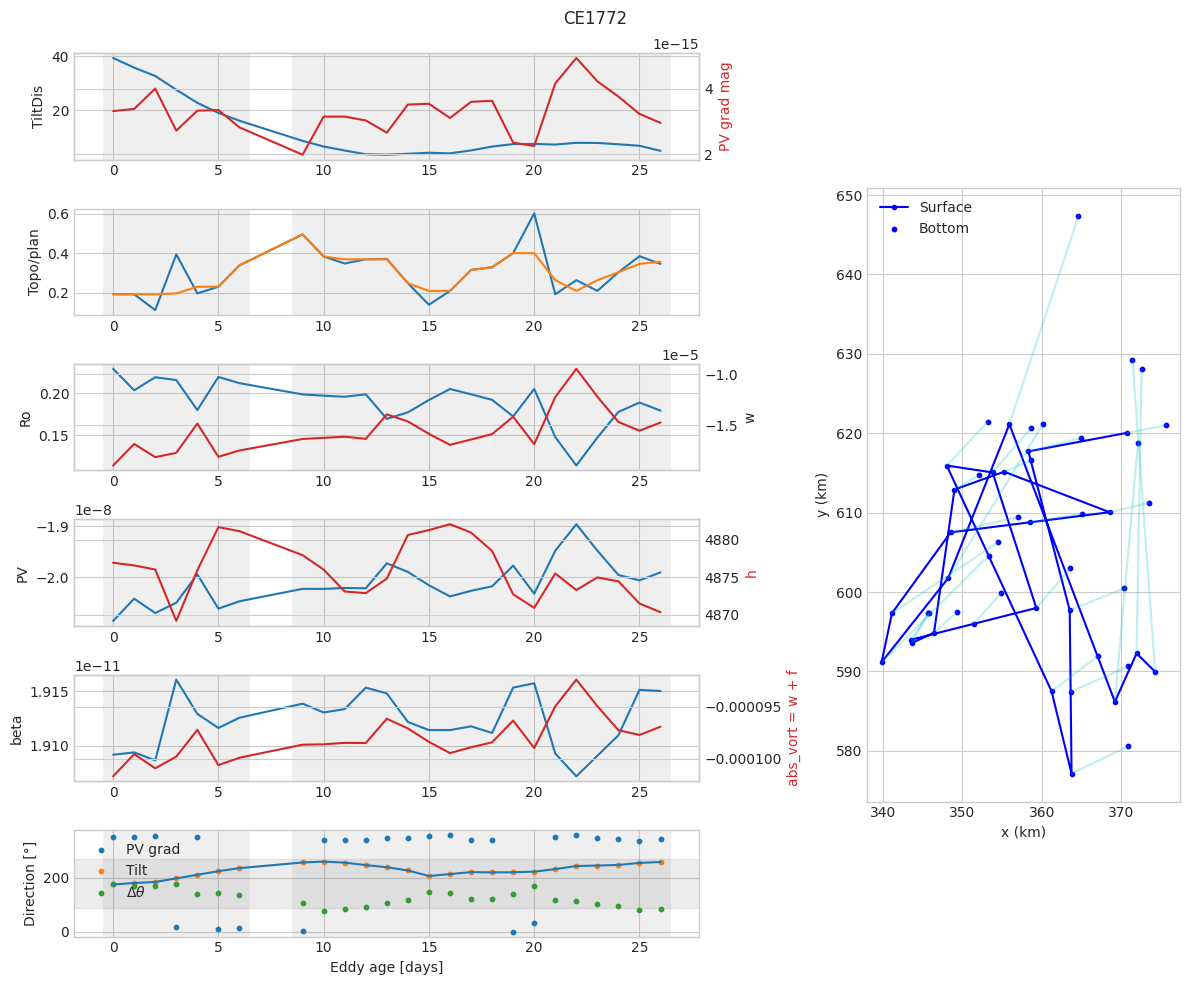

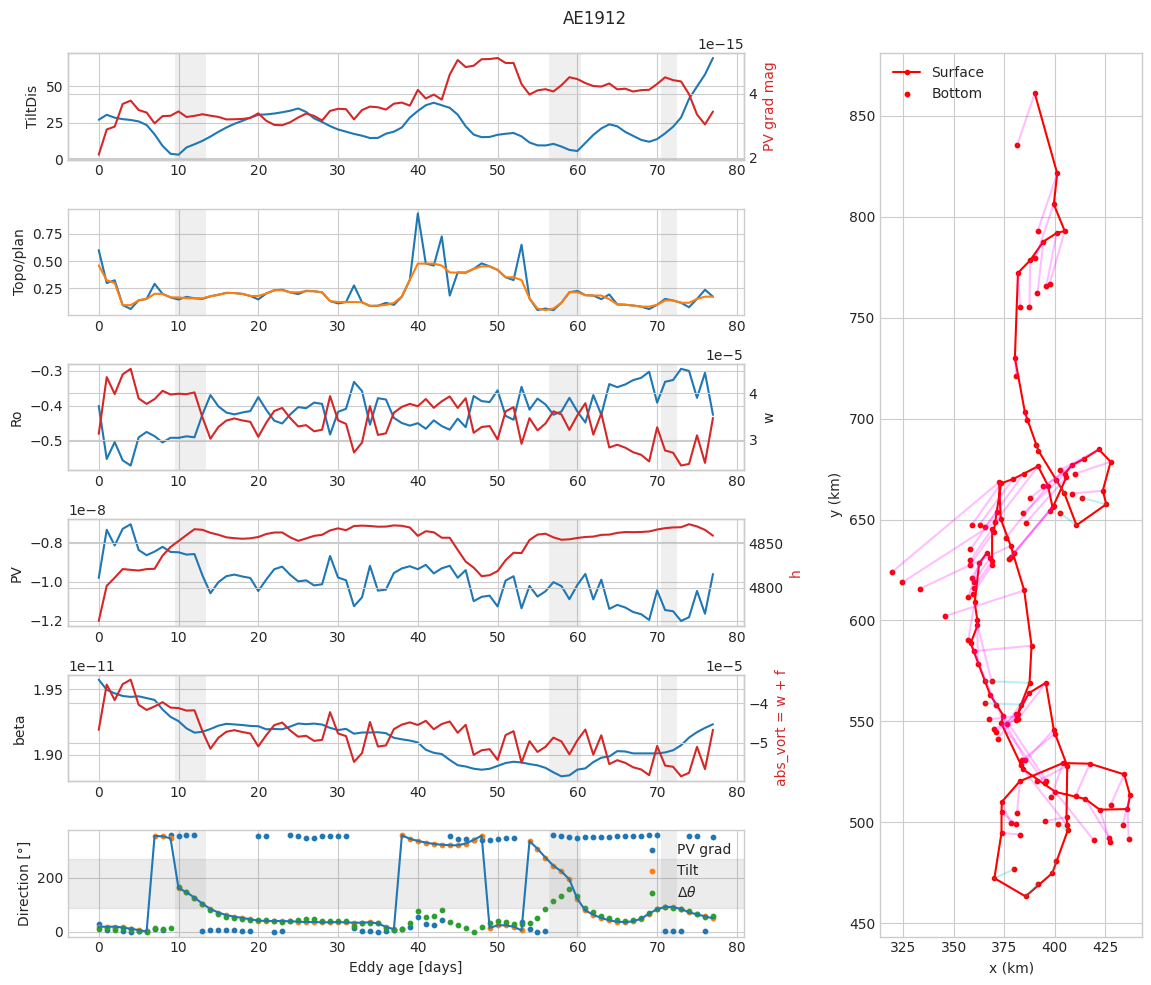

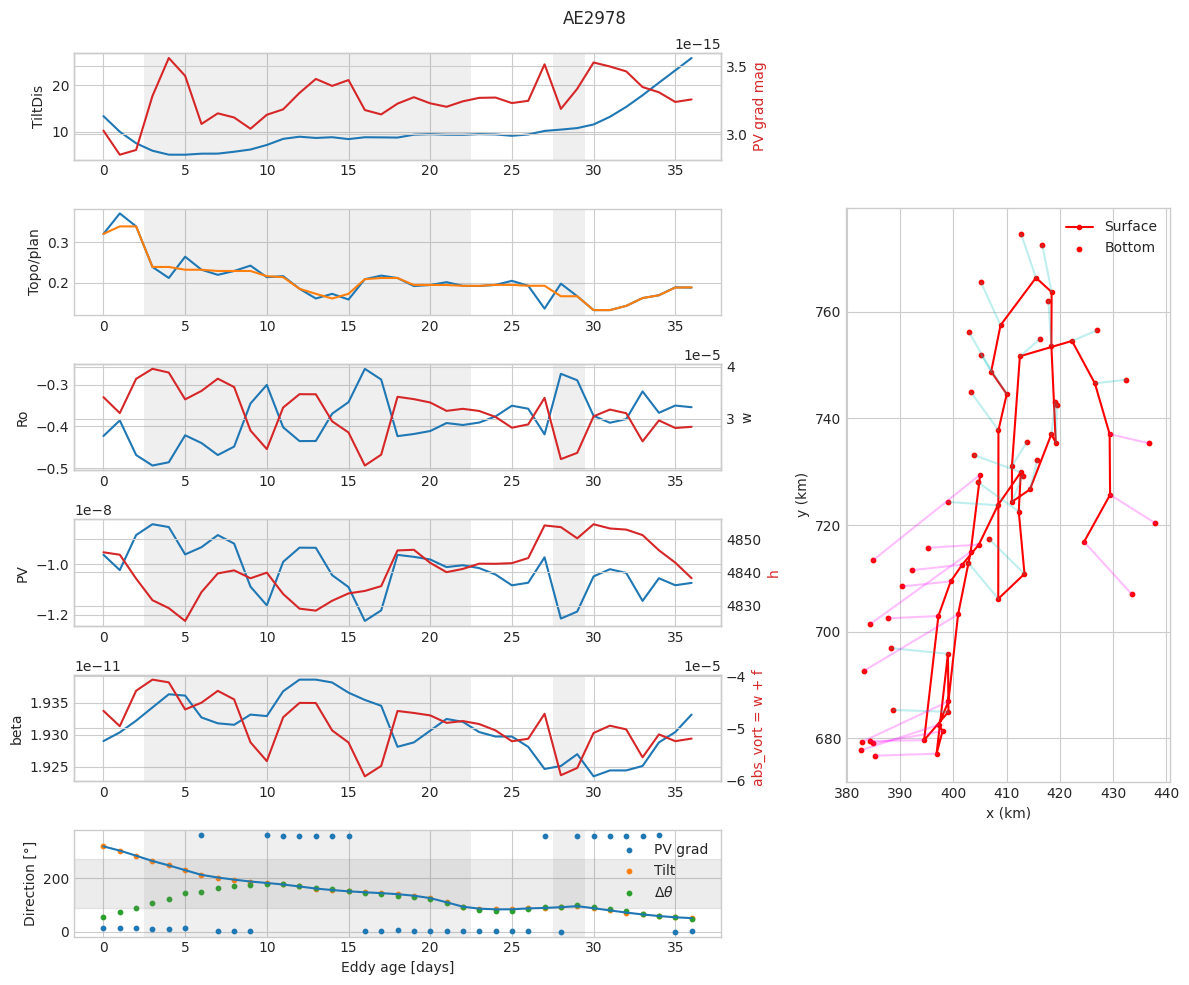

In [11]:
for eddy in df_complete.Eddy.unique():
    time_plot(eddy, df_complete)

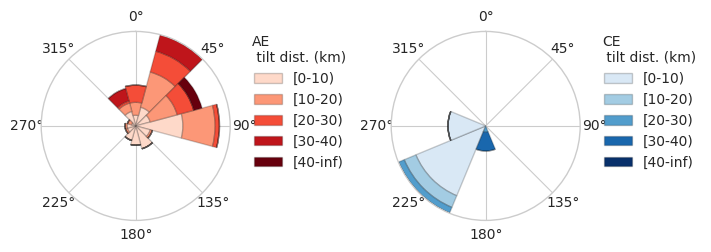

In [12]:
fig, axs = plt.subplots(1, 2, figsize=(7, 4), subplot_kw={"projection": "polar"}, constrained_layout=True)
mag_bins = [0, 10, 20, 30, 40, np.inf]
for ax, cyc, colors in zip(axs, ["AE", "CE"], [plt.cm.Reds(np.linspace(0.15, 1, len(mag_bins) - 1)), plt.cm.Blues(np.linspace(0.15, 1, len(mag_bins) - 1))]):
    subset = df_complete.loc[df_complete.Cyc == cyc].dropna(subset=["TiltDir", "TiltDis"])
    tilt.plot_windrose(ax, subset, title='', mag_bins=mag_bins, colors=colors)
    ax.legend(title=f"{cyc}\n tilt dist. (km)", loc="upper left", bbox_to_anchor=(1.05, 1.05), frameon=False)
    ax.set_rticks([])
plt.show()

In [18]:
df_eddies.TiltDis.mean(), planetary.TiltDis.mean()

(np.float64(23.866543131899274), np.float64(19.652241253904617))